In [1]:
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scipy.linalg import eigh
import pandas as pd
import plotly.graph_objects as go

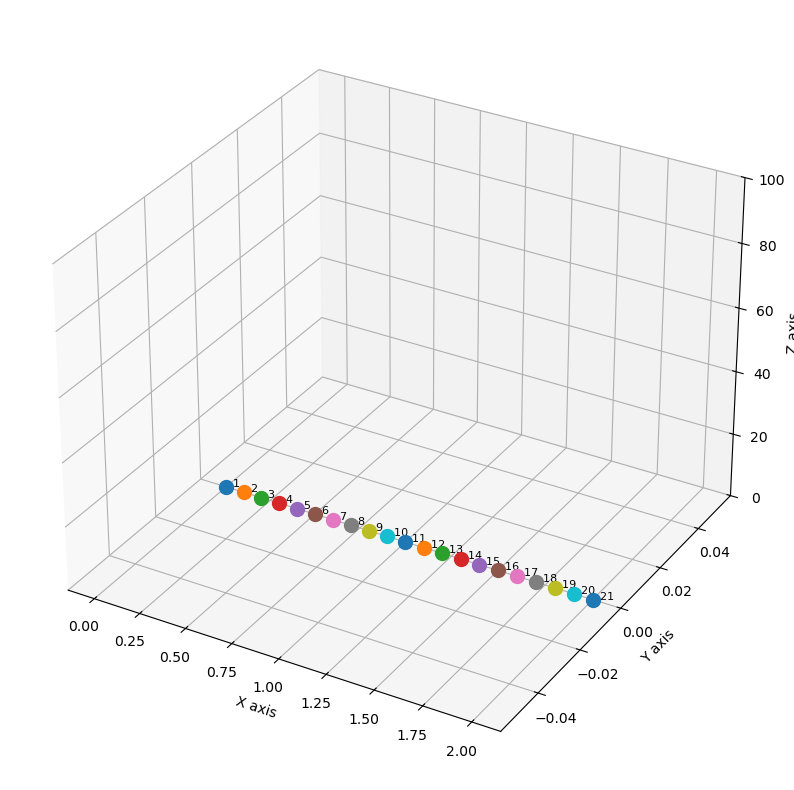

In [2]:
# Create nodes using a loop
nodes = []
for i in range(21):
    nodes.append(n.nodes(i * 0.1, 0, 0))

# Unpack nodes to individual variables for compatibility with existing code
n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12, n13, n14, n15, n16, n17, n18, n19, n20, n21 = nodes[:21]

n.plot_nodes(nodes)

In [3]:

E=210e9
rho=7850
b=0.05
h=0.1
A=b*h
Iy=b*h**3/12
Iz=h*b**3/12
It = (b*h**3) *1000
L = 0.1
Ip = ((h**2 + b**2) / 12 )* (L * h * b * rho)
k = 5/6 
G= E/(2*(1+0.3))


ep_K = [E, G, A, Iy, Iz, It, k]
ep_M = [rho, A, Iy, Iz, Ip]



In [4]:
e1 = e.elements(n1, n2, ep_K, ep_M)
e2 = e.elements(n2, n3, ep_K, ep_M)
e3 = e.elements(n3, n4, ep_K, ep_M)
e4 = e.elements(n4, n5, ep_K, ep_M)
e5 = e.elements(n5, n6, ep_K, ep_M)
e6 = e.elements(n6, n7, ep_K, ep_M)
e7 = e.elements(n7, n8, ep_K, ep_M)
e8 = e.elements(n8, n9, ep_K, ep_M)
e9 = e.elements(n9, n10, ep_K, ep_M)
e10 = e.elements(n10, n11, ep_K, ep_M)
e11 = e.elements(n11, n12, ep_K, ep_M)
e12 = e.elements(n12, n13, ep_K, ep_M)
e13 = e.elements(n13, n14, ep_K, ep_M)
e14 = e.elements(n14, n15, ep_K, ep_M)
e15 = e.elements(n15, n16, ep_K, ep_M)
e16 = e.elements(n16, n17, ep_K, ep_M)
e17 = e.elements(n17, n18, ep_K, ep_M)
e18 = e.elements(n18, n19, ep_K, ep_M)
e19 = e.elements(n19, n20, ep_K, ep_M)
e20 = e.elements(n20, n21, ep_K, ep_M)  

elements = [e1, e2, e3, e4, e5, e6, e7, e8, e9, e10, e11, e12, e13, e14, e15, e16, e17, e18, e19, e20]

element_nodes = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), 
                 (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), 
                 (17, 18), (18, 19), (19, 20), (20, 21)]

dofs = n.degrees_of_freedom(nodes)

element_locs = []

for (nA, nB) in element_nodes:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))


In [5]:
N = len(nodes)
DOFS_per_node = 6



K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))

K_locs = []
M_locs = []



for i in range(len(element_locs)):
    K_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-1]
    M_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-2]



# To restore symmetry of the global stiffness and mass matrices
K_global = 0.5 * (K_global + K_global.T)
M_global = 0.5 * (M_global + M_global.T)


In [6]:
indices_to_remove = np.hstack((dofs['dof_1'][0:3], dofs['dof_21'][0:3]))
keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)
K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]


In [7]:
eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)

frequencies_rad = np.sqrt(eigvals_global)
frequencies_hz = frequencies_rad / (2 * np.pi)



data_freqs = pd.DataFrame({
    'Frequency (Hz)': frequencies_hz,
    'Frequency (rad/s)': frequencies_rad
})

display(data_freqs[:10])

C:\Users\alami\AppData\Local\Temp\ipykernel_36344\2212267911.py:3: RuntimeWarning: invalid value encountered in sqrt
  frequencies_rad = np.sqrt(eigvals_global)


,Frequency (Hz),Frequency (rad/s)
0,NaN,NaN
1,29.285667,184.007273
2,58.386351,366.852260
3,116.774808,733.717756
4,230.649658,1449.214540
5,261.391200,1642.369346
6,461.428681,2899.241911
7,508.578221,3195.491204
8,714.670250,4490.405611
9,879.909939,5528.637201


In [8]:
eigvecs_full = e.expand_eigenvectors(eigvecs_global, keep_indices, N*DOFS_per_node)
print("Expanded eigenvectors shape:", eigvecs_full.shape)

Expanded eigenvectors shape: (126, 120)


In [9]:
eigvecs_disp_full = e.extract_displacement(eigvecs_full, keep=3, skip=3)
eigvecs_full.shape


(126, 120)

In [10]:
modes_to_plot = 10
modes = []
for i in range(modes_to_plot):
    modes.append(eigvecs_disp_full[:, i].reshape(-1, 3) + nodes)

In [11]:
for i in range(modes_to_plot):
    line_x = []
    line_y = []
    line_z = []
    for nA, nB in element_nodes:
        p1 = modes[i][nA - 1]
        p2 = modes[i][nB - 1]
        line_x.extend([p1[0], p2[0], None])
        line_y.extend([p1[1], p2[1], None])
        line_z.extend([p1[2], p2[2], None])

    fig_lines = go.Figure(
        data=[
            go.Scatter3d(
                x=line_x,
                y=line_y,
                z=line_z,
                mode='lines',
                line=dict(color='black', width=2)
            ),
            go.Scatter3d(
                x=modes[i][:, 0],
                y=modes[i][:, 1],
                z=modes[i][:, 2],
                mode='markers',
                marker=dict(size=3, color='blue')
            )
        ]
    )

    X = modes[i][:, 0]
    Y = modes[i][:, 1]
    Z = modes[i][:, 2]
    e.set_equal_aspect(fig_lines, X, Y, Z)

    fig_lines.update_layout(
        title=f'Mode {i+1} - Deformed Configuration (Elements)',
        scene=dict(
            xaxis_title='X (m)',
            yaxis_title='Y (m)',
            zaxis_title='Z (m)'
        ),
        width=900,
        height=700
    )

    fig_lines.show()

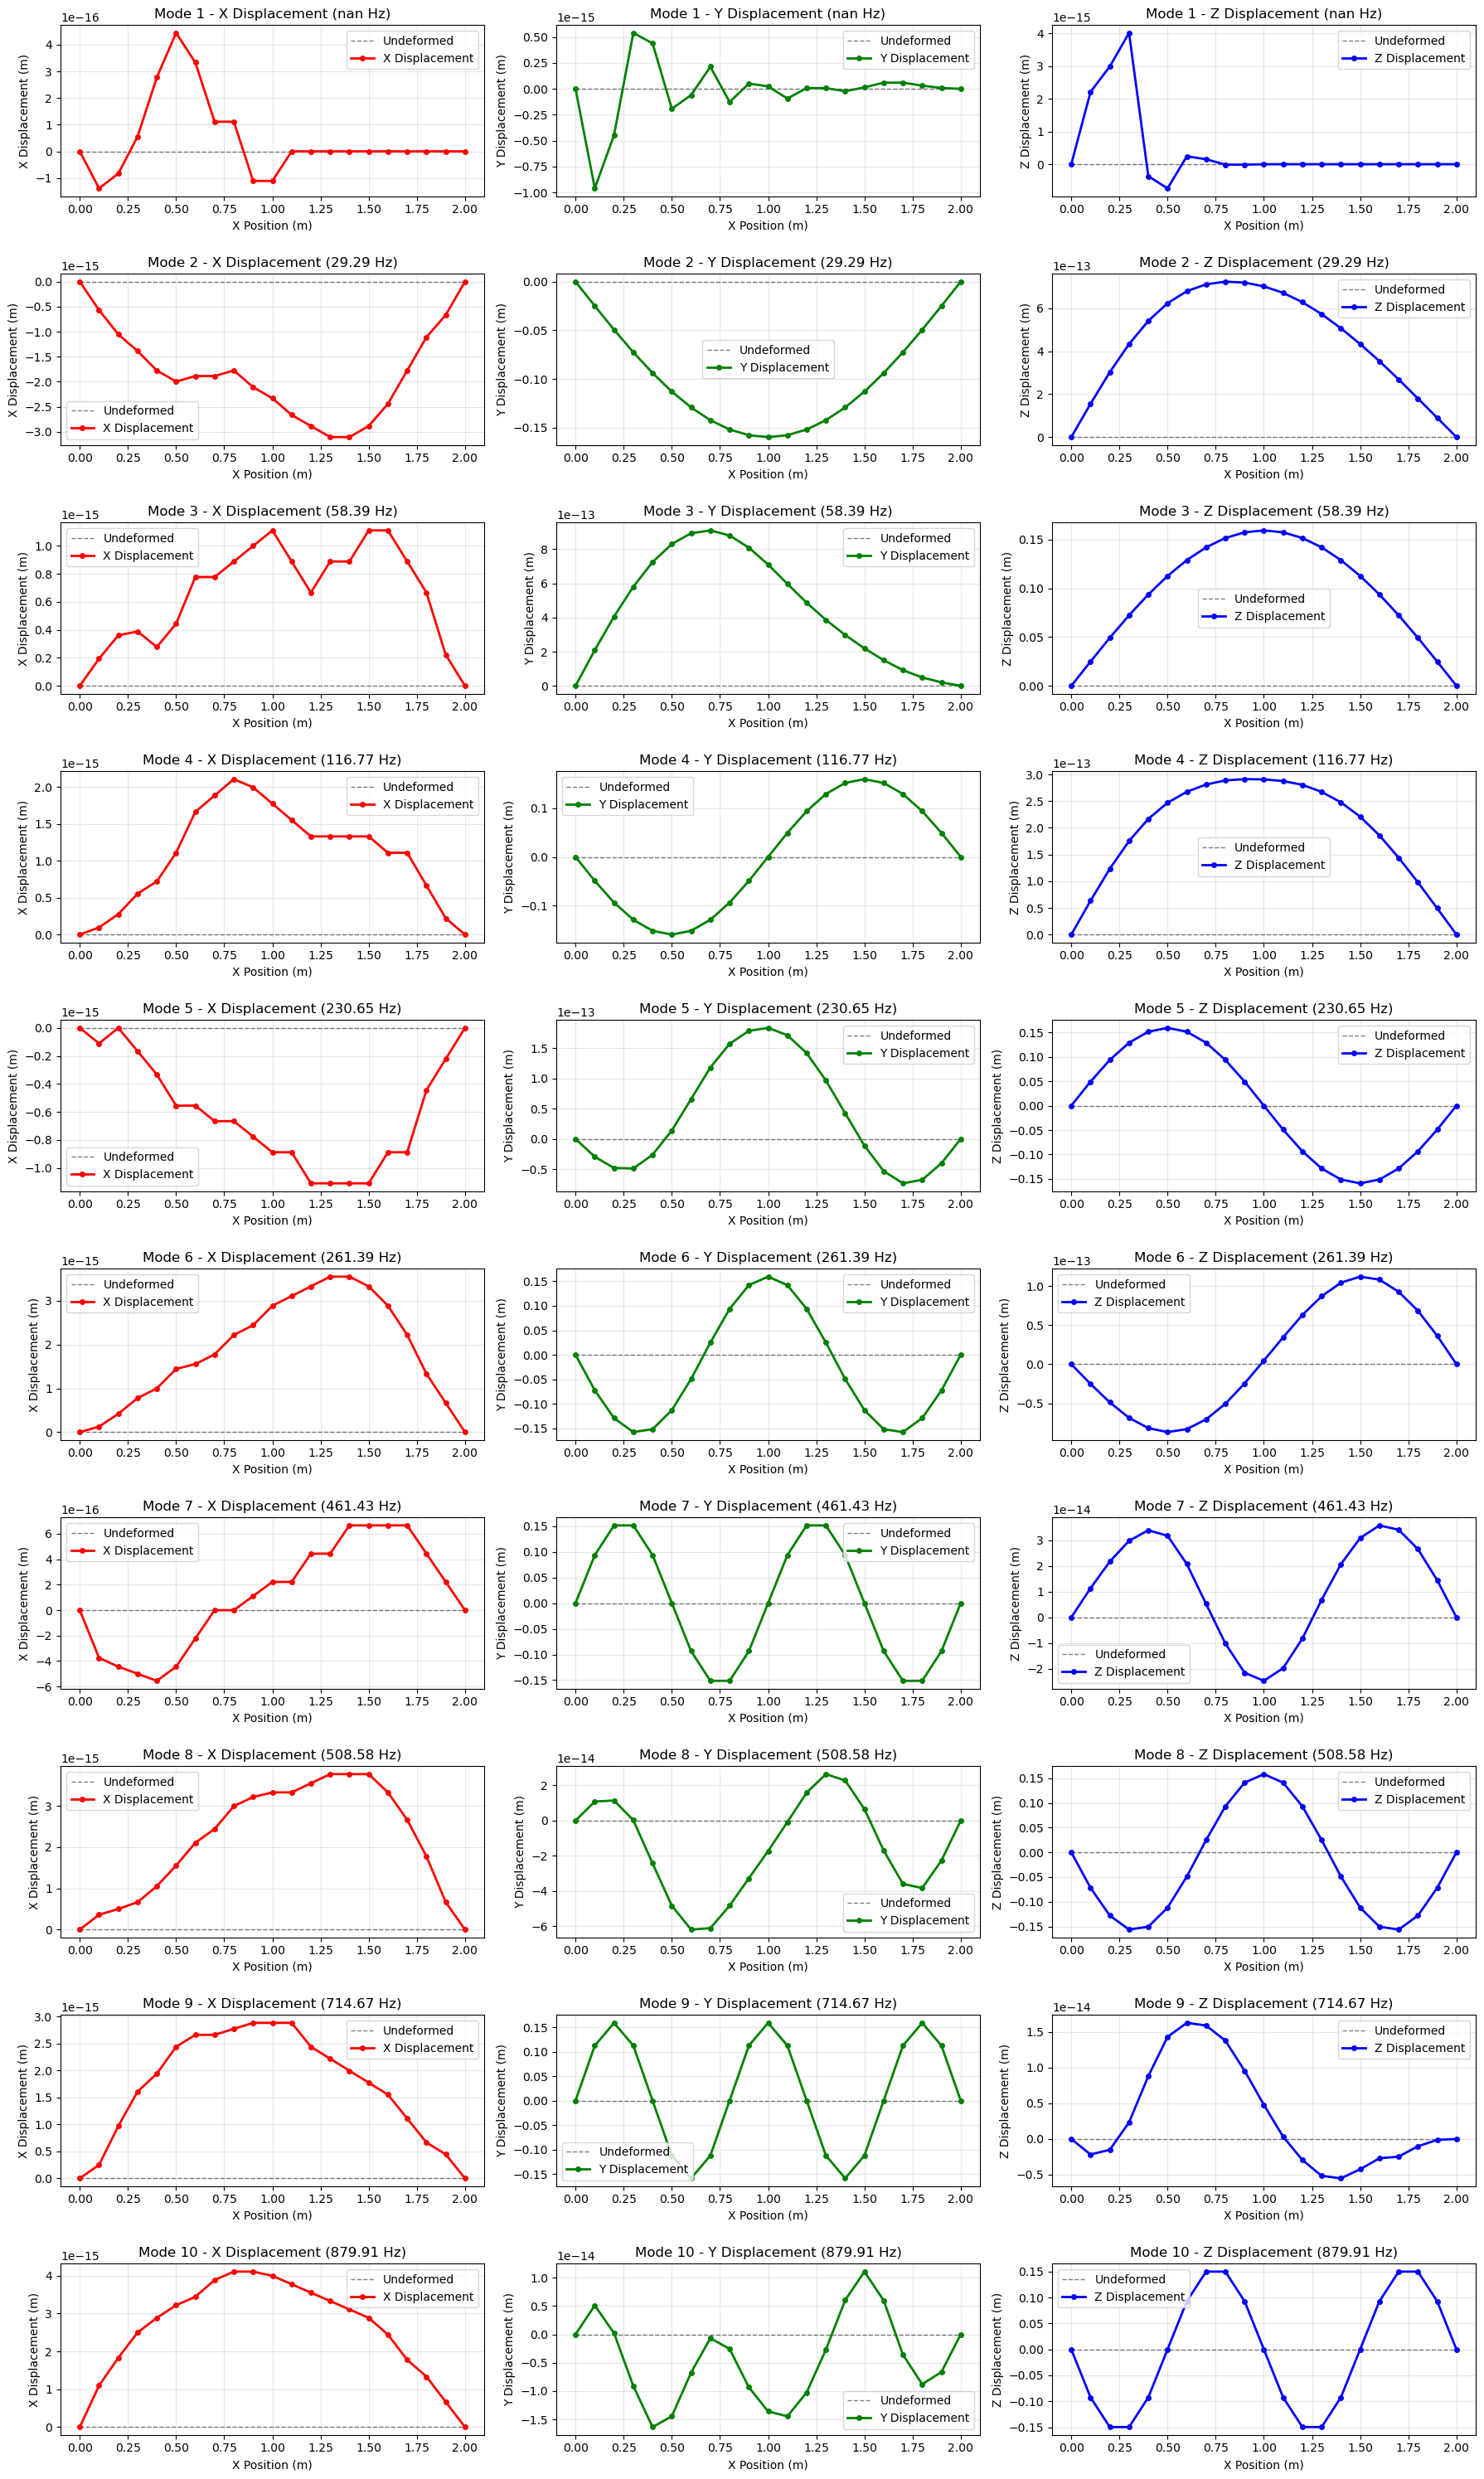

In [12]:
fig, axes = plt.subplots(modes_to_plot, 3, figsize=(18, 3*modes_to_plot))

for i in range(modes_to_plot):
    # X displacement
    ax_x = axes[i, 0] if modes_to_plot > 1 else axes[0]
    x_undeformed = [node[0] for node in nodes]
    x_deformed = modes[i][:, 0]
    ax_x.plot(x_undeformed, [0]*len(nodes), 'k--', linewidth=1, label='Undeformed', alpha=0.5)
    ax_x.plot(x_undeformed, x_deformed - x_undeformed, 'r-', linewidth=2, label='X Displacement', marker='o', markersize=4)
    ax_x.set_xlabel('X Position (m)')
    ax_x.set_ylabel('X Displacement (m)')
    ax_x.set_title(f'Mode {i+1} - X Displacement ({frequencies_hz[i]:.2f} Hz)')
    ax_x.grid(True, alpha=0.3)
    ax_x.legend()
    
    # Y displacement
    ax_y = axes[i, 1] if modes_to_plot > 1 else axes[1]
    y_deformed = modes[i][:, 1]
    ax_y.plot(x_undeformed, [0]*len(nodes), 'k--', linewidth=1, label='Undeformed', alpha=0.5)
    ax_y.plot(x_undeformed, y_deformed, 'g-', linewidth=2, label='Y Displacement', marker='o', markersize=4)
    ax_y.set_xlabel('X Position (m)')
    ax_y.set_ylabel('Y Displacement (m)')
    ax_y.set_title(f'Mode {i+1} - Y Displacement ({frequencies_hz[i]:.2f} Hz)')
    ax_y.grid(True, alpha=0.3)
    ax_y.legend()
    
    # Z displacement
    ax_z = axes[i, 2] if modes_to_plot > 1 else axes[2]
    z_undeformed = [node[2] for node in nodes]
    z_deformed = modes[i][:, 2]
    ax_z.plot(x_undeformed, z_undeformed, 'k--', linewidth=1, label='Undeformed', alpha=0.5)
    ax_z.plot(x_undeformed, z_deformed, 'b-', linewidth=2, label='Z Displacement', marker='o', markersize=4)
    ax_z.set_xlabel('X Position (m)')
    ax_z.set_ylabel('Z Displacement (m)')
    ax_z.set_title(f'Mode {i+1} - Z Displacement ({frequencies_hz[i]:.2f} Hz)')
    ax_z.grid(True, alpha=0.3)
    ax_z.legend()

plt.tight_layout()
plt.show()